# This Notebook is a trained model of Disease Identification

## EDA (Exploratory Data Analysis)

In [1]:
import tensorflow as tf
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os

### Loading Dataset

In [3]:
dataset = "./Dataset/DISEASE_DETECTION_DATASET"
classes = os.listdir(dataset)
print("Plant Classes:", classes)
print("Number of Classes:", len(classes))

Plant Classes: ['Aloe_Anthracnose', 'Aloe_LeafSpot', 'Aloe_Rust', 'Aloe_Sunburn', 'blight-hibiscus', 'blight-rose', 'Cactus_Dactylopius_Opuntia', 'death_leaf-dwarf_white_bauhinia', 'death_leaf-hibiscus', 'early_blight-night_flowering_jasmine', 'insect_bite-crapejasmine', 'Money_Plant_Bacterial_wilt_disease', 'Money_Plant_Manganese_Toxicity', 'red_spot-night_flowering_jasmine', 'scorch-bananabush', 'scorch-hibiscus', 'Snake_Plant_Anthracnose', 'Snake_Plant_Leaf_Withering', 'Spider_Plant_Fungal_leaf_spot', 'Spider_Plant_Leaf_Tip_Necrosis']
Number of Classes: 20


In [4]:
data = []
for plant in classes:
    plant_path = os.path.join(dataset,plant)

    if os.path.isdir(plant_path):
        images = os.listdir(plant_path)
        data.append([plant,len(images)])

df = pd.DataFrame(data, columns=["Plant Name","Image Count"])
print(df)

                              Plant Name  Image Count
0                       Aloe_Anthracnose         3007
1                          Aloe_LeafSpot         3024
2                              Aloe_Rust         1552
3                           Aloe_Sunburn         3053
4                        blight-hibiscus         1000
5                            blight-rose         1000
6             Cactus_Dactylopius_Opuntia          274
7        death_leaf-dwarf_white_bauhinia         1000
8                    death_leaf-hibiscus         1000
9   early_blight-night_flowering_jasmine         1000
10              insect_bite-crapejasmine         1000
11    Money_Plant_Bacterial_wilt_disease          135
12        Money_Plant_Manganese_Toxicity          144
13      red_spot-night_flowering_jasmine         1000
14                     scorch-bananabush         1000
15                       scorch-hibiscus         1000
16               Snake_Plant_Anthracnose          177
17            Snake_Plant_Le

### Distribution of number of images per plant

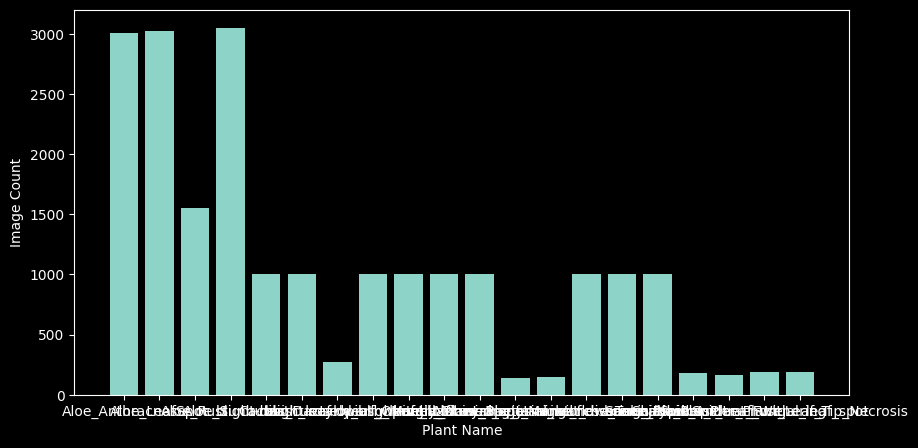

In [5]:
plt.figure(figsize=(10,5))
plt.bar(df["Plant Name"],df["Image Count"])
plt.xlabel("Plant Name")
plt.ylabel("Image Count")
plt.show()

### Checking Image shapes

In [6]:
sizes = []
for plant in classes:
    plant_path = os.path.join(dataset,plant)
    images = os.listdir(plant_path)

    for img_name in images[:5]:
        img_path = os.path.join(plant_path,img_name)
        img = cv2.imread(img_path)

        if img is not None:
            sizes.append(img.shape)

print("Sample Image Sizes", sizes[:10])

Sample Image Sizes [(4080, 3072, 3), (3024, 4032, 3), (1377, 1905, 3), (4080, 3072, 3), (1512, 2016, 3), (4080, 3072, 3), (4080, 3072, 3), (1649, 1121, 3), (4032, 3024, 3), (1128, 2000, 3)]


## EfficientNet Model Implementation

### Imports

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

### Hyperparameters

In [8]:
IMG_SIZE = 224 # EfficientNetB0 default size
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(classes)

### Data Preparation

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print("Number of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 20912 files belonging to 20 classes.
Using 16730 files for training.
Found 20912 files belonging to 20 classes.
Using 4182 files for validation.
Number of training batches: 523
Number of validation batches: 131


### Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

### Building EfficientNet Model

In [11]:
def build_efficientnet_model(num_classes):
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    base_model = EfficientNetB0(include_top=False, input_tensor=x, weights="imagenet")

    base_model.trainable = False

    x = GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = BatchNormalization()(x)
    x = Dropout(0.3, name="top_dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="pred")(x)

    model = Model(inputs, outputs, name="EfficientNet_PlantID")

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

    return model


model = build_efficientnet_model(NUM_CLASSES)
model.summary()

Model: "EfficientNet_PlantID"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,080,311 (15.57 MB)

 Trainable params: 28,180 (110.08 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Checking Images which are other than RGB

In [12]:
from PIL import Image
import os

issues = []

for class_name in os.listdir(dataset):
    class_path = os.path.join(dataset, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            channels = len(img.getbands())
            if channels != 3:
                issues.append((fpath, img.mode, channels))
        except Exception as e:
            issues.append((fpath, "CORRUPT", str(e)))

print(f"Found {len(issues)} problematic files:\n")
for path, mode, ch in issues:
    print(f"  {mode:>6} ({ch} ch) — {path}")

Found 43 problematic files:

    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00137.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00206.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00298.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00344.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00385.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00456.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00487.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00491.png
    RGBA (4 ch) — ./Dataset/DISEASE_DETECTION_DATASET\Aloe_Anthracnose\processed_img_Anthracnose00495.png
    RGBA (4 ch) —

### Converting to RGB

In [14]:
from PIL import Image
import os

issues = []

for class_name in os.listdir(dataset):
    class_path = os.path.join(dataset, class_name)

    if not os.path.isdir(class_path):
        continue

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)

        try:
            img = Image.open(fpath)

            # 🔥 Convert EVERYTHING to RGB (fixes grayscale, RGBA, etc.)
            img = img.convert("RGB")
            img.save(fpath)

        except Exception as e:
            # If image is corrupt → track it (optional: delete)
            issues.append((fpath, str(e)))

print(f"Found {len(issues)} corrupt files.")

Found 0 corrupt files.


In [15]:
def preprocessing_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

### Training the model

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Starting training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Starting training...
Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 471s 883ms/step - accuracy: 0.7068 - loss: 0.8273 - val_accuracy: 0.8123 - val_loss: 0.4833
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 592s 1s/step - accuracy: 0.7863 - loss: 0.5480 - val_accuracy: 0.8204 - val_loss: 0.4627
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.8036 - loss: 0.5018 - val_accuracy: 0.8271 - val_loss: 0.4419
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.8042 - loss: 0.4947 - val_accuracy: 0.8364 - val_loss: 0.4272
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 632s 1s/step - accuracy: 0.8140 - loss: 0.4817 - val_accuracy: 0.8312 - val_loss: 0.4229
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 756s 1s/step - accuracy: 0.8136 - loss: 0.4791 - val_accuracy: 0.8345 - val_loss: 0.4160
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.8175 - loss: 0.4703 - val_accuracy: 0.8345 - val_loss: 0.4103
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.8173 -

### Final training and validation accuracy & training and validation loss

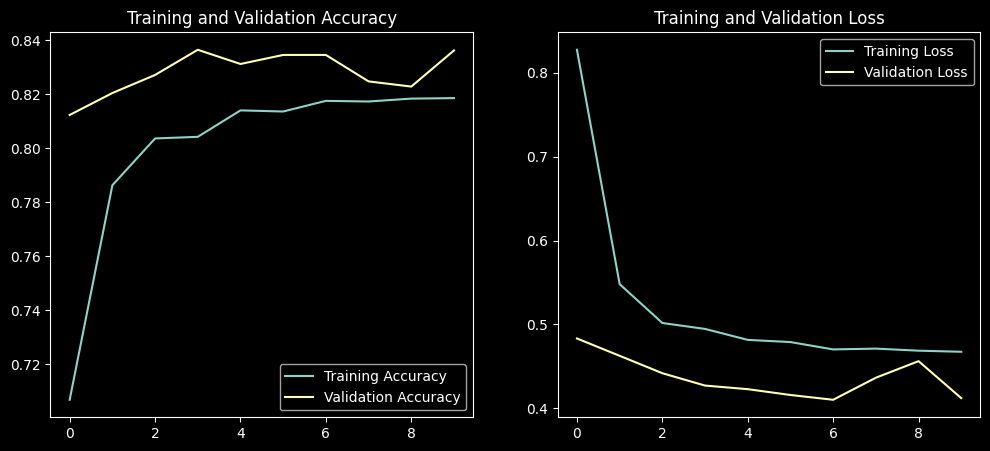

In [17]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

if 'history' in locals():
    plot_history(history)

## Saving the model

In [19]:
model.save("./plantdisease_efficientnet_model.keras")
print("Model saved!")

Model saved!
